# Total stack warpage calculation for a 16-die stack

This notebook implements the updated multilayer warpage model with initial die warpage:

`kappa = (M_D0 + M_T + M_b) / (K_D + K_a)`

`W = kappa * L^2 / 2`

All calculations use SI units internally. Positive signed initial bow means positive signed curvature under `W0 = kappa0 * L^2 / 2`. Edit the layer table and `DeltaT` below for your stack.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 6)


## Model implementation

Input layer columns:

- `h_um`: layer thickness in micrometers
- `E_GPa`: Young's modulus in GPa
- `nu`: Poisson's ratio
- `alpha_ppm_K`: effective CTE in ppm/K
- `W0_um`: signed initial bow in micrometers over half-length `L_m`

The notebook converts `W0_um` to natural initial curvature using `kappa0 = 2 W0 / L^2`.

In [2]:
def bow_um_to_curvature(W0_um, L_m):
    """Convert signed bow in um to signed curvature in 1/m."""
    return 2.0 * (np.asarray(W0_um, dtype=float) * 1e-6) / (L_m**2)


def curvature_to_bow_um(kappa, L_m):
    """Convert signed curvature in 1/m to signed bow in um."""
    return 0.5 * kappa * L_m**2 * 1e6


def compute_total_stack_warpage(layer_df, DeltaT_K, L_m):
    """Compute final signed curvature, total bow, layer forces, and stresses.

    This uses the sign convention in the updated note:

        M_T - K_a*kappa + M_b - K_D*kappa + M_D0 = 0
        kappa = (M_D0 + M_T + M_b) / (K_D + K_a)

    `kappa0` is interpreted as each layer's stress-free natural curvature.
    """
    required = ["h_um", "E_GPa", "nu", "alpha_ppm_K", "W0_um"]
    missing = [col for col in required if col not in layer_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = layer_df.copy().reset_index(drop=True)
    h = df["h_um"].to_numpy(dtype=float) * 1e-6
    E = df["E_GPa"].to_numpy(dtype=float) * 1e9
    nu = df["nu"].to_numpy(dtype=float)
    alpha = df["alpha_ppm_K"].to_numpy(dtype=float) * 1e-6
    kappa0 = bow_um_to_curvature(df["W0_um"].to_numpy(dtype=float), L_m)

    if np.any(h <= 0):
        raise ValueError("All layer thicknesses must be positive.")
    if np.any((nu <= -1.0) | (nu >= 0.5)):
        raise ValueError("Poisson ratios should be in the elastic range (-1, 0.5).")

    E_biaxial = E / (1.0 - nu)
    lam = 1.0 / (E_biaxial * h)
    weights = 1.0 / lam

    h_cumsum = np.cumsum(h)
    hk0_cumsum = np.cumsum(h * kappa0)

    # a_i is distance from layer i mid-plane to layer 0 mid-plane.
    a = h_cumsum - 0.5 * (h[0] + h)

    # b_i is the initial-curvature analogue of a_i*kappa, so it is strain-like.
    b = hk0_cumsum - 0.5 * (h[0] * kappa0[0] + h * kappa0)

    delta_alpha = alpha - alpha[0]
    s_alpha = np.sum(delta_alpha * weights) / np.sum(weights)
    s_a = np.sum(a * weights) / np.sum(weights)
    s_b = np.sum(b * weights) / np.sum(weights)

    D = E_biaxial * h**3 / 12.0
    M_T = np.sum((a / lam) * (delta_alpha - s_alpha) * DeltaT_K)
    M_b = np.sum((a / lam) * (b - s_b))
    K_a = np.sum((a / lam) * (a - s_a))
    K_D = np.sum(D)
    M_D0 = np.sum(D * kappa0)

    kappa = (M_D0 + M_T + M_b) / (K_D + K_a)
    W_um = curvature_to_bow_um(kappa, L_m)

    strain_term = (delta_alpha - s_alpha) * DeltaT_K - (a - s_a) * kappa + (b - s_b)
    F = weights * strain_term
    sigma = E_biaxial * strain_term

    moment_residual = np.sum(F * a) - np.sum(D * (kappa - kappa0))

    layer_out = df.copy()
    layer_out["E_biaxial_GPa"] = E_biaxial / 1e9
    layer_out["kappa0_1_per_m"] = kappa0
    layer_out["a_um"] = a * 1e6
    layer_out["b_microstrain"] = b * 1e6
    layer_out["force_N_per_m"] = F
    layer_out["stress_MPa"] = sigma / 1e6

    summary = {
        "n_layers": len(df),
        "DeltaT_K": DeltaT_K,
        "L_m": L_m,
        "die_full_length_mm": 2.0 * L_m * 1e3,
        "kappa_1_per_m": kappa,
        "radius_m": np.inf if np.isclose(kappa, 0.0) else 1.0 / kappa,
        "signed_W_um": W_um,
        "abs_W_um": abs(W_um),
        "M_T_N": M_T,
        "M_b_N": M_b,
        "M_D0_N": M_D0,
        "K_a_N_m": K_a,
        "K_D_N_m": K_D,
        "force_residual_N_per_m": np.sum(F),
        "moment_residual_N": moment_residual,
    }

    return summary, layer_out


## Example: 16-layer die stack

This is a placeholder example, not a process-calibrated stack. Replace the thickness, effective modulus, CTE, and signed initial bow values with measured or extracted die-level data.

Here `DeltaT_K` can represent cooling from anneal/bonding temperature to room temperature. If you want the pre-anneal room-temperature stack with no thermal source, set `DeltaT_K = 0`.

In [31]:
# Geometry: 10 mm x 10 mm die, so L is the half-length used in W = kappa*L^2/2.
L_m = 5.0e-3

# Example thermal step: cooling by 275 K, e.g. 300 C to 25 C.
# Use DeltaT_K = 0.0 for pre-anneal room-temperature stacking without thermal mismatch.
DeltaT_K = -275.0

n_layers = 16
rng = np.random.default_rng(263)

# A synthetic 16-die stack. Values are intentionally close to silicon-like properties
# with small effective-die variations. Replace these values for real studies.
layers = pd.DataFrame({
    "layer": np.arange(n_layers),
    "h_um": np.ones(n_layers) * 50.0,
    "E_GPa": np.ones(n_layers) * 130.0,
    "nu": np.full(n_layers, 0.28),
    "alpha_ppm_K": 2.60 + np.linspace(-0.04, 0.06, n_layers),
    "W0_um": np.zeros(n_layers),
})

layers


,layer,h_um,E_GPa,nu,alpha_ppm_K,W0_um
0,0,50.0,130.0,0.28,2.560000,0.0
1,1,50.0,130.0,0.28,2.566667,0.0
2,2,50.0,130.0,0.28,2.573333,0.0
3,3,50.0,130.0,0.28,2.580000,0.0
4,4,50.0,130.0,0.28,2.586667,0.0
5,5,50.0,130.0,0.28,2.593333,0.0
6,6,50.0,130.0,0.28,2.600000,0.0
7,7,50.0,130.0,0.28,2.606667,0.0
8,8,50.0,130.0,0.28,2.613333,0.0
9,9,50.0,130.0,0.28,2.620000,0.0


In [32]:
summary, layer_results = compute_total_stack_warpage(layers, DeltaT_K=DeltaT_K, L_m=L_m)

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
summary_df


,value
n_layers,1.600000e+01
DeltaT_K,-2.750000e+02
L_m,5.000000e-03
die_full_length_mm,1.000000e+01
kappa_1_per_m,-3.652344e-02
radius_m,-2.737968e+01
signed_W_um,-4.565430e-01
abs_W_um,4.565430e-01
M_T_N,-2.813657e-01
M_b_N,0.000000e+00


In [33]:
print(f"Final signed curvature: {summary['kappa_1_per_m']:.6g} 1/m")
print(f"Final signed total bow: {summary['signed_W_um']:.6g} um")
print(f"Final absolute total bow: {summary['abs_W_um']:.6g} um")
print(f"Force residual: {summary['force_residual_N_per_m']:.3e} N/m")
print(f"Moment residual: {summary['moment_residual_N']:.3e} N")


Final signed curvature: -0.0365234 1/m
Final signed total bow: -0.456543 um
Final absolute total bow: 0.456543 um
Force residual: 9.948e-14 N/m
Moment residual: -6.050e-17 N


In [34]:
layer_results[[
    "layer", "h_um", "E_GPa", "nu", "alpha_ppm_K", "W0_um",
    "kappa0_1_per_m", "a_um", "b_microstrain", "force_N_per_m", "stress_MPa"
]]


,layer,h_um,E_GPa,nu,alpha_ppm_K,W0_um,kappa0_1_per_m,a_um,b_microstrain,force_N_per_m,stress_MPa
0,0,50.0,130.0,0.28,2.560000,0.0,0.0,0.0,0.0,0.484890,0.009698
1,1,50.0,130.0,0.28,2.566667,0.0,0.0,50.0,0.0,0.420238,0.008405
2,2,50.0,130.0,0.28,2.573333,0.0,0.0,100.0,0.0,0.355586,0.007112
3,3,50.0,130.0,0.28,2.580000,0.0,0.0,150.0,0.0,0.290934,0.005819
4,4,50.0,130.0,0.28,2.586667,0.0,0.0,200.0,0.0,0.226282,0.004526
5,5,50.0,130.0,0.28,2.593333,0.0,0.0,250.0,0.0,0.161630,0.003233
6,6,50.0,130.0,0.28,2.600000,0.0,0.0,300.0,0.0,0.096978,0.001940
7,7,50.0,130.0,0.28,2.606667,0.0,0.0,350.0,0.0,0.032326,0.000647
8,8,50.0,130.0,0.28,2.613333,0.0,0.0,400.0,0.0,-0.032326,-0.000647
9,9,50.0,130.0,0.28,2.620000,0.0,0.0,450.0,0.0,-0.096978,-0.001940


## Plot final warpage profile

The parabolic profile below uses `w(x) = kappa*x^2/2`. It is the global stack bow model, not local Cu pad deformation.

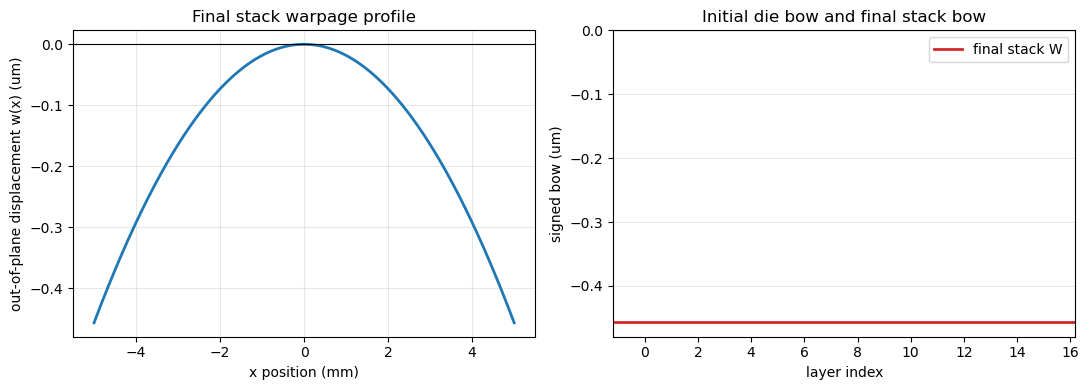

In [35]:
x = np.linspace(-L_m, L_m, 401)
w_um = 0.5 * summary["kappa_1_per_m"] * x**2 * 1e6

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x * 1e3, w_um, lw=2)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("x position (mm)")
axes[0].set_ylabel("out-of-plane displacement w(x) (um)")
axes[0].set_title("Final stack warpage profile")
axes[0].grid(True, alpha=0.3)

axes[1].bar(layer_results["layer"], layer_results["W0_um"], color="tab:blue")
axes[1].axhline(summary["signed_W_um"], color="tab:red", lw=2, label="final stack W")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("layer index")
axes[1].set_ylabel("signed bow (um)")
axes[1].set_title("Initial die bow and final stack bow")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Compare pre-anneal and post-cooldown cases

This cell reuses the same initial warpage values and compares `DeltaT = 0` against the selected post-cooldown `DeltaT_K`.

In [36]:
cases = []
for name, dT in [("pre-anneal, DeltaT=0", 0.0), ("post-cooldown", DeltaT_K)]:
    s, _ = compute_total_stack_warpage(layers, DeltaT_K=dT, L_m=L_m)
    cases.append({
        "case": name,
        "DeltaT_K": dT,
        "kappa_1_per_m": s["kappa_1_per_m"],
        "signed_W_um": s["signed_W_um"],
        "abs_W_um": s["abs_W_um"],
    })

pd.DataFrame(cases)


,case,DeltaT_K,kappa_1_per_m,signed_W_um,abs_W_um
0,"pre-anneal, DeltaT=0",0.0,0.000000,0.000000,0.000000
1,post-cooldown,-275.0,-0.036523,-0.456543,0.456543
